In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:

!nvidia-smi



Thu Dec 12 17:24:01 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   60C    P8              10W /  70W |      0MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/25], Loss: 1.0628, Accuracy: 0.5635
Epoch [2/25], Loss: 0.7682, Accuracy: 0.6802
Epoch [3/25], Loss: 0.7043, Accuracy: 0.7462
Epoch [4/25], Loss: 0.5139, Accuracy: 0.8198
Epoch [5/25], Loss: 0.6101, Accuracy: 0.7817
Epoch [6/25], Loss: 0.3996, Accuracy: 0.8503
Epoch [7/25], Loss: 0.4977, Accuracy: 0.8147
Epoch [8/25], Loss: 0.5098, Accuracy: 0.8274
Epoch [9/25], Loss: 0.3422, Accuracy: 0.8680
Epoch [10/25], Loss: 0.3315, Accuracy: 0.8883
Epoch [11/25], Loss: 0.3313, Accuracy: 0.8959
Epoch [12/25], Loss: 0.3826, Accuracy: 0.8604
Epoch [13/25], Loss: 0.3381, Accuracy: 0.8655
Epoch [14/25], Loss: 0.3093, Accuracy: 0.8832
Epoch [15/25], Loss: 0.1979, Accuracy: 0.9264
Epoch [16/25], Loss: 0.1588, Accuracy: 0.9391
Epoch [17/25], Loss: 0.4286, Accuracy: 0.8604
Epoch [18/25], Loss: 0.2316, Accuracy: 0.9289
Epoch [19/25], Loss: 0.2178, Accuracy: 0.9365
Epoch [20/25], Loss: 0.2493, Accuracy: 0.9289
Epoch [21/25], Loss: 0.2326, Accuracy: 0.9213
Epoch [22/25], Loss: 0.2635, Accuracy: 0.91

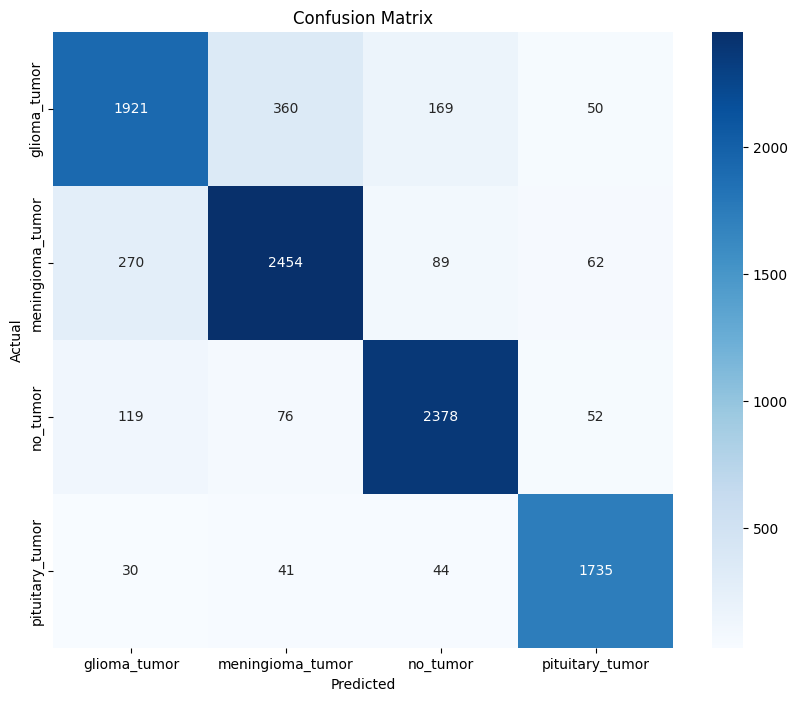

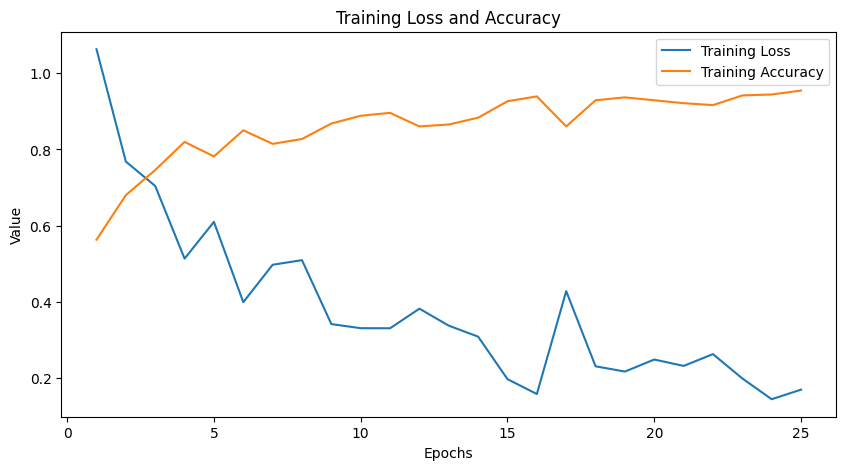

In [9]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Set paths and parameters
dataset_dir = '/content/drive/MyDrive/sample'
batch_size = 16
learning_rate = 0.001
epochs = 25
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Data transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Load dataset
train_data = datasets.ImageFolder(root=dataset_dir, transform=transform)
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

# Define the model
model = models.resnet18(pretrained=True)
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 512),
    nn.ReLU(),
    nn.Dropout(0.4),
    nn.Linear(512, len(train_data.classes))
)
model = model.to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Training loop
model.train()
all_preds = []
all_labels = []
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(train_data)
    epoch_acc = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}')

# Save the trained model and class list
model_save_path = '/content/drive/MyDrive/brain_tumor_model.pth'
classes_save_path = '/content/drive/MyDrive/brain_tumor_classes.npy'

torch.save(model.state_dict(), model_save_path)
np.save(classes_save_path, np.array(train_data.classes))

print(f"Model saved at {model_save_path}")
print(f"Classes saved at {classes_save_path}")

# Evaluation Metrics
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=train_data.classes))

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=train_data.classes, yticklabels=train_data.classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Training Loss and Accuracy Plots
plt.figure(figsize=(10, 5))
plt.plot(range(1, epochs+1), train_losses, label='Training Loss')
plt.plot(range(1, epochs+1), train_accuracies, label='Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.title('Training Loss and Accuracy')
plt.legend()
plt.show()


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda
